In [9]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import mip

%matplotlib inline

np.random.seed(4321)
n = 5
m = 3

D = [i for i in range(n)]
S = [j for j in range(m)]

Si = {i: set(np.random.randint(0, m, size=3)) for i in D}
C = [np.random.randint(1, 10) for i in D]
A = [(i,j) for i in D for j in Si[i]]

B = np.random.randint(1, max([len(Si[i]) for i in Si]), size=m)

print('Sets:')
print('\tD:', D)
print('\tS:', S)
print('\tA:', A)
print()
print('Parameters:')
print('\tSi:', Si)
print('\tC:', C)
print('\tB:', B)

Sets:
	D: [0, 1, 2, 3, 4]
	S: [0, 1, 2]
	A: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 2), (2, 1), (3, 0), (3, 2), (4, 0), (4, 1)]

Parameters:
	Si: {0: {0, 1, 2}, 1: {0, 2}, 2: {1}, 3: {0, 2}, 4: {0, 1}}
	C: [9, 7, 6, 4, 2]
	B: [2 1 2]


In [2]:
m = mip.Model()
vars = {(i,j): m.add_var(var_type=mip.BINARY) for (i,j) in A}
selected = [m.add_var(var_type=mip.BINARY) for i in D]

for j in S:
    m.add_constr(mip.xsum(vars[i, j] for (i, j1) in A if j == j1) >= B[j])
for i in D:
    m.add_constr(selected[i] >= mip.xsum(vars[i,j] for (i1,j) in A if i1 == i))

m.objective = mip.minimize(mip.xsum(C[i]*selected[i] for i in D))
m.optimize()

Welcome to the CBC MILP Solver 
Version: Trunk
Build Date: Oct 24 2021 

Starting solution of the Linear programming relaxation problem using Primal Simplex

Coin0506I Presolve 4 (-4) rows, 9 (-6) columns and 13 (-12) elements
Clp1000I sum of infeasibilities 2.48273e-06 - average 6.20682e-07, 5 fixed columns
Coin0506I Presolve 0 (-4) rows, 0 (-9) columns and 0 (-13) elements
Clp0000I Optimal - objective value 28
Clp0000I Optimal - objective value 28
Coin0511I After Postsolve, objective 28, infeasibilities - dual 0 (0), primal 0 (0)
Clp0000I Optimal - objective value 28
Clp0000I Optimal - objective value 28
Clp0000I Optimal - objective value 28
Coin0511I After Postsolve, objective 28, infeasibilities - dual 0 (0), primal 0 (0)
Clp0032I Optimal objective 28 - 0 iterations time 0.002, Presolve 0.00, Idiot 0.00

Starting MIP optimization


<OptimizationStatus.OPTIMAL: 0>

In [8]:
print('Solution:')
for v in vars:
    print(f'\t{v} {vars[v].x}')

print('Selected doctors:', [i for (i,s) in enumerate(selected) if s.x >= 0.9])

cost = 0
for i, d in enumerate(selected):
    if d.x >= 0.9:
        cost += C[i]
print('Total cost:', cost)

Solution:
	(0, 0) 0.0
	(0, 1) 0.0
	(0, 2) 1.0
	(1, 0) 0.0
	(1, 2) 1.0
	(2, 1) 1.0
	(3, 0) 1.0
	(3, 2) 0.0
	(4, 0) 1.0
	(4, 1) 0.0
Selected doctors:  [0, 1, 2, 3, 4]
Total cost:  28


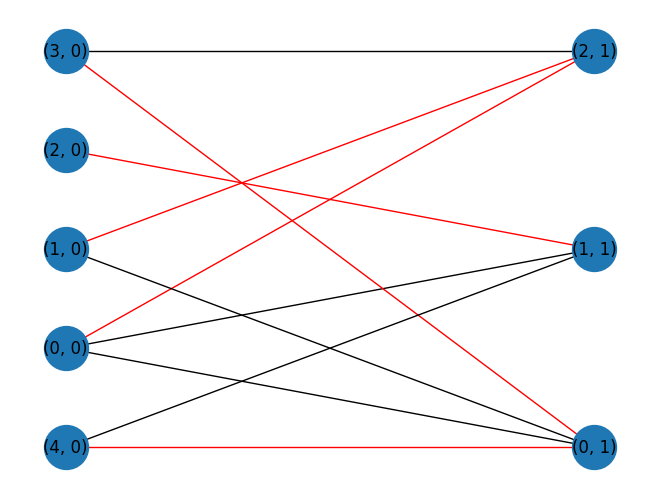

In [4]:
def draw_bipartite(D, S, A):
    G = nx.Graph()

    wrap_D = [(i,0) for i in D]
    wrap_S = [(j,1) for j in S]
    G.add_nodes_from(wrap_D, bipartite=0)
    G.add_nodes_from(wrap_S, bipartite=1)

    wrap_A = [ ((i,0), (j,1)) for (i,j) in A]
    G.add_edges_from(wrap_A)

    colors = ['red' if vars[i,j].x >= 0.9 else 'black' for (i,j) in A]

    pos = nx.bipartite_layout(G, nx.bipartite.sets(G)[0])
    nx.draw(G, pos, edge_color=colors, with_labels=True, node_size=1000)
    plt.show()
draw_bipartite(D, S, A)